## Índice

1. Objetivo
2. Importación de librerías
3. Exploración de PM2.5
4. Exploración de Meteorología
5. Catálogo de estaciones
6. Integración GIS
7. Pipeline
8. Arquitectura
9. Conclusiones

# Objetivo

Explorar, validar e integrar los principales datasets ambientales, meteorológicos y geoespaciales del proyecto, verificando su compatibilidad para construir una base de datos consolidada que permita el desarrollo de modelos de aprendizaje automático orientados a la identificación de zonas críticas de contaminación atmosférica en la Ciudad de México.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
from pathlib import Path

# Buscar todos los archivos dentro de la carpeta de datos
carpeta = Path("../datos")

for archivo in carpeta.rglob("*"):
    print(archivo)

..\datos\datos_limpios
..\datos\gis
..\datos\metereologicos
..\datos\simat
..\datos\sinaica
..\datos\datos_limpios\dataset_limpios
..\datos\datos_limpios\dataset_limpios.zip
..\datos\gis\bases_ambiental
..\datos\gis\bases_ambiental.zip
..\datos\datos_limpios\dataset_limpios\dataset_limpios
..\datos\datos_limpios\dataset_limpios\dataset_limpios\Catalogo_Estaciones.csv
..\datos\datos_limpios\dataset_limpios\dataset_limpios\Catalogo_Estaciones.ipynb
..\datos\datos_limpios\dataset_limpios\dataset_limpios\dataset_limpios
..\datos\datos_limpios\dataset_limpios\dataset_limpios\ETL_Geografia.ipynb
..\datos\datos_limpios\dataset_limpios\dataset_limpios\ETL_Meteorologia.ipynb
..\datos\datos_limpios\dataset_limpios\dataset_limpios\ETL_PM25.ipynb
..\datos\datos_limpios\dataset_limpios\dataset_limpios\Geografia
..\datos\datos_limpios\dataset_limpios\dataset_limpios\Meteorologia_24_25
..\datos\datos_limpios\dataset_limpios\dataset_limpios\PM25_24_25
..\datos\datos_limpios\dataset_limpios\dataset_lim

# Exploración técnica de datasets

## Proyecto
Identificación de zonas críticas de contaminación atmosférica mediante técnicas GIS y aprendizaje automático utilizando concentraciones de PM2.5 registradas en la Ciudad de México durante el periodo 2024–2025.
## Responsable Técnico
Miranda Patricia Pérez Camelo
## Objetivo
Validar la lectura de los datasets proporcionados, explorar su estructura, identificar sus principales variables y verificar la posibilidad de integrarlos en un pipeline de procesamiento para las siguientes fases del proyecto.

In [3]:
ruta_pm25_2024 = Path(
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/PM25_24_25/24PM25_limpio.csv"
)

pm25_2024 = pd.read_csv(ruta_pm25_2024)

print("PM2.5 2024 cargado correctamente")

PM2.5 2024 cargado correctamente


In [4]:
pm25_2024.head()

,FECHA,HORA,AJM,AJU,BJU,CAM,CCA,COY,FAR,GAM,...,NEZ,PED,SAC,SAG,SFE,SJA,TLA,UAX,UIZ,XAL
0,2024-01-01,1,33.0,NaN,42.0,46.0,NaN,NaN,NaN,NaN,...,NaN,51.0,107.0,55.0,NaN,NaN,62.0,NaN,66.0,NaN
1,2024-01-01,2,21.0,NaN,53.0,66.0,44.0,NaN,69.0,NaN,...,NaN,62.0,150.0,65.0,NaN,NaN,74.0,NaN,95.0,NaN
2,2024-01-01,3,18.0,NaN,71.0,91.0,58.0,NaN,70.0,NaN,...,NaN,NaN,185.0,109.0,NaN,NaN,94.0,NaN,135.0,NaN
3,2024-01-01,4,17.0,NaN,108.0,104.0,77.0,NaN,118.0,NaN,...,NaN,NaN,252.0,136.0,NaN,NaN,67.0,NaN,156.0,NaN
4,2024-01-01,5,18.0,NaN,116.0,142.0,87.0,NaN,195.0,NaN,...,NaN,NaN,312.0,165.0,NaN,NaN,43.0,NaN,236.0,NaN


In [5]:
pm25_2024.shape

(8782, 26)

In [6]:
pm25_2024.columns

Index(['FECHA', 'HORA', 'AJM', 'AJU', 'BJU', 'CAM', 'CCA', 'COY', 'FAR', 'GAM',
       'HGM', 'INN', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG',
       'SFE', 'SJA', 'TLA', 'UAX', 'UIZ', 'XAL'],
      dtype='str')

In [7]:
pm25_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FECHA   8782 non-null   str    
 1   HORA    8782 non-null   int64  
 2   AJM     7605 non-null   float64
 3   AJU     0 non-null      float64
 4   BJU     6720 non-null   float64
 5   CAM     7165 non-null   float64
 6   CCA     7578 non-null   float64
 7   COY     0 non-null      float64
 8   FAR     6949 non-null   float64
 9   GAM     4389 non-null   float64
 10  HGM     4668 non-null   float64
 11  INN     3945 non-null   float64
 12  MER     7307 non-null   float64
 13  MGH     0 non-null      float64
 14  MON     5769 non-null   float64
 15  MPA     5670 non-null   float64
 16  NEZ     3315 non-null   float64
 17  PED     7589 non-null   float64
 18  SAC     7624 non-null   float64
 19  SAG     6010 non-null   float64
 20  SFE     0 non-null      float64
 21  SJA     0 non-null      float64
 22  TLA     502

In [8]:
pm25_2024.describe()

,HORA,AJM,AJU,BJU,CAM,CCA,COY,FAR,GAM,HGM,...,NEZ,PED,SAC,SAG,SFE,SJA,TLA,UAX,UIZ,XAL
count,8782.000000,7605.000000,0.0,6720.000000,7165.000000,7578.000000,0.0,6949.000000,4389.000000,4668.000000,...,3315.000000,7589.000000,7624.000000,6010.000000,0.0,0.0,5021.000000,3415.000000,5134.000000,0.0
mean,12.497950,16.358054,NaN,21.484375,23.087369,18.186329,NaN,20.433588,21.973798,21.754070,...,18.747210,18.079852,25.032135,22.818303,NaN,NaN,22.559849,19.182430,23.921309,NaN
std,6.921933,10.928754,NaN,12.726322,13.437145,11.399919,NaN,13.221828,12.531273,12.076178,...,14.763087,11.369875,16.991595,13.041018,NaN,NaN,13.349599,12.445656,13.955708,NaN
min,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,NaN
25%,6.250000,8.000000,NaN,12.000000,13.000000,10.000000,NaN,11.000000,13.000000,13.000000,...,9.000000,10.000000,14.000000,14.000000,NaN,NaN,13.000000,11.000000,15.000000,NaN
50%,12.000000,14.000000,NaN,19.000000,21.000000,16.000000,NaN,18.000000,20.000000,20.000000,...,16.000000,16.000000,22.000000,21.000000,NaN,NaN,20.000000,17.000000,22.000000,NaN
75%,18.000000,22.000000,NaN,28.000000,30.000000,24.000000,NaN,27.000000,29.000000,28.000000,...,24.000000,24.000000,32.000000,29.000000,NaN,NaN,30.000000,25.000000,30.000000,NaN
max,24.000000,98.000000,NaN,159.000000,142.000000,109.000000,NaN,195.000000,98.000000,112.000000,...,191.000000,129.000000,312.000000,227.000000,NaN,NaN,102.000000,133.000000,236.000000,NaN


In [9]:
pm25_2024.isnull().sum()

FECHA       0
HORA        0
AJM      1177
AJU      8782
BJU      2062
CAM      1617
CCA      1204
COY      8782
FAR      1833
GAM      4393
HGM      4114
INN      4837
MER      1475
MGH      8782
MON      3013
MPA      3112
NEZ      5467
PED      1193
SAC      1158
SAG      2772
SFE      8782
SJA      8782
TLA      3761
UAX      5367
UIZ      3648
XAL      8782
dtype: int64

### Conclusión de la exploración del dataset PM2.5

El dataset fue leído correctamente desde Python; se identificó una estructura basada en FECHA, HORA y estaciones de monitoreo; se detectó la presencia de valores faltantes en algunas estaciones, lo cual deberá considerarse en las etapas de integración de datos y análisis.

## 2. Exploración del dataset de Temperatura (TMP)
En esta sección se valida la lectura del dataset de temperatura correspondiente al año 2024, con el objetivo de verificar su estructura, dimensiones y compatibilidad con el dataset de PM2.5 para una futura integración.

In [10]:
ruta_tmp_2024 = Path(
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Meteorologia_24_25/TMP_2024_Limpio.csv"
)

tmp_2024 = pd.read_csv(ruta_tmp_2024)

print("Dataset de temperatura cargado correctamente")

Dataset de temperatura cargado correctamente


In [11]:
tmp_2024.head()

,FECHA,HORA,ACO,AJM,AJU,BJU,CHO,CUA,CUT,FAC,...,PED,SAC,SAG,SFE,TAH,TLA,UAX,UIZ,VIF,XAL
0,2024-01-01,1,NaN,6.0,1.0,12.0,NaN,11.0,8.0,8.0,...,10.0,9.0,13.0,NaN,9.0,NaN,NaN,11.0,NaN,NaN
1,2024-01-01,2,NaN,5.0,1.0,11.0,NaN,10.0,7.0,7.0,...,10.0,8.0,11.0,NaN,9.0,NaN,NaN,10.0,NaN,NaN
2,2024-01-01,3,NaN,4.0,1.0,11.0,NaN,10.0,6.0,5.0,...,NaN,7.0,11.0,NaN,7.0,NaN,NaN,10.0,NaN,NaN
3,2024-01-01,4,NaN,4.0,1.0,10.0,NaN,9.0,6.0,4.0,...,NaN,7.0,11.0,NaN,7.0,NaN,NaN,9.0,NaN,NaN
4,2024-01-01,5,NaN,3.0,1.0,10.0,NaN,9.0,5.0,4.0,...,NaN,6.0,10.0,NaN,7.0,NaN,NaN,9.0,NaN,NaN


In [12]:
tmp_2024.shape

(8776, 30)

In [13]:
tmp_2024.columns

Index(['FECHA', 'HORA', 'ACO', 'AJM', 'AJU', 'BJU', 'CHO', 'CUA', 'CUT', 'FAC',
       'FAR', 'GAM', 'HGM', 'INN', 'LAA', 'MER', 'MGH', 'MON', 'MPA', 'NEZ',
       'PED', 'SAC', 'SAG', 'SFE', 'TAH', 'TLA', 'UAX', 'UIZ', 'VIF', 'XAL'],
      dtype='str')

In [14]:
tmp_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 8776 entries, 0 to 8775
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FECHA   8776 non-null   str    
 1   HORA    8776 non-null   int64  
 2   ACO     1230 non-null   float64
 3   AJM     5766 non-null   float64
 4   AJU     8458 non-null   float64
 5   BJU     7840 non-null   float64
 6   CHO     0 non-null      float64
 7   CUA     4310 non-null   float64
 8   CUT     8320 non-null   float64
 9   FAC     8545 non-null   float64
 10  FAR     1225 non-null   float64
 11  GAM     8135 non-null   float64
 12  HGM     0 non-null      float64
 13  INN     7612 non-null   float64
 14  LAA     2918 non-null   float64
 15  MER     7171 non-null   float64
 16  MGH     4961 non-null   float64
 17  MON     6195 non-null   float64
 18  MPA     4208 non-null   float64
 19  NEZ     8631 non-null   float64
 20  PED     6633 non-null   float64
 21  SAC     4675 non-null   float64
 22  SAG     827

In [15]:
tmp_2024.describe()

,HORA,ACO,AJM,AJU,BJU,CHO,CUA,CUT,FAC,FAR,...,PED,SAC,SAG,SFE,TAH,TLA,UAX,UIZ,VIF,XAL
count,8776.000000,1230.000000,5766.000000,8458.000000,7840.000000,0.0,4310.000000,8320.000000,8545.000000,1225.000000,...,6633.000000,4675.000000,8276.000000,0.0,2921.000000,0.0,1134.000000,4884.000000,1271.000000,0.0
mean,12.503418,12.185041,14.463545,11.251431,19.126798,NaN,16.105777,16.949111,17.378947,15.650694,...,17.428826,18.952642,19.651909,NaN,15.039370,NaN,16.012257,18.992875,15.752478,NaN
std,6.920994,7.009390,5.526551,5.593243,4.562405,NaN,3.718008,6.295536,6.616749,5.277567,...,4.830880,6.073979,4.891587,NaN,5.643056,NaN,5.096925,4.718608,5.108766,NaN
min,1.000000,-1.600000,-1.000000,-3.900000,7.600000,NaN,5.000000,0.300000,0.300000,4.100000,...,6.000000,3.000000,5.800000,NaN,2.000000,NaN,6.100000,6.000000,5.000000,NaN
25%,7.000000,6.600000,10.200000,7.800000,15.800000,NaN,13.400000,12.800000,13.000000,11.400000,...,14.000000,14.400000,16.200000,NaN,10.700000,NaN,11.900000,15.600000,11.700000,NaN
50%,13.000000,11.400000,14.000000,11.300000,18.500000,NaN,15.200000,16.150000,16.500000,15.400000,...,16.900000,18.300000,19.100000,NaN,14.500000,NaN,15.500000,18.600000,15.100000,NaN
75%,18.250000,18.000000,18.600000,15.200000,22.300000,NaN,18.600000,21.400000,22.300000,19.700000,...,20.900000,23.500000,23.000000,NaN,19.200000,NaN,20.000000,22.400000,19.850000,NaN
max,24.000000,27.100000,29.700000,26.100000,32.500000,NaN,30.600000,35.900000,35.300000,27.300000,...,30.700000,34.100000,33.700000,NaN,29.500000,NaN,27.400000,31.200000,27.400000,NaN


In [16]:
tmp_2024.isnull().sum()

FECHA       0
HORA        0
ACO      7546
AJM      3010
AJU       318
BJU       936
CHO      8776
CUA      4466
CUT       456
FAC       231
FAR      7551
GAM       641
HGM      8776
INN      1164
LAA      5858
MER      1605
MGH      3815
MON      2581
MPA      4568
NEZ       145
PED      2143
SAC      4101
SAG       500
SFE      8776
TAH      5855
TLA      8776
UAX      7642
UIZ      3892
VIF      7505
XAL      8776
dtype: int64

### Conclusión de la exploración del dataset Temperatura

El dataset de temperatura presenta una estructura compatible con la del dataset de PM2.5, ya que utiliza FECHA, HORA y estaciones de monitoreo como variables principales; sin embargo, se observaron diferencias en el número de registros y estaciones disponibles, por lo que será necesario validar las coincidencias antes de integrar ambos conjuntos de datos.

In [17]:
estaciones_pm25 = set(pm25_2024.columns) - {"FECHA", "HORA"}
estaciones_tmp = set(tmp_2024.columns) - {"FECHA", "HORA"}

print("Estaciones comunes:")
print(sorted(estaciones_pm25 & estaciones_tmp))

print("\nSolo PM2.5:")
print(sorted(estaciones_pm25 - estaciones_tmp))

print("\nSolo Temperatura:")
print(sorted(estaciones_tmp - estaciones_pm25))

Estaciones comunes:
['AJM', 'AJU', 'BJU', 'FAR', 'GAM', 'HGM', 'INN', 'MER', 'MGH', 'MON', 'MPA', 'NEZ', 'PED', 'SAC', 'SAG', 'SFE', 'TLA', 'UAX', 'UIZ', 'XAL']

Solo PM2.5:
['CAM', 'CCA', 'COY', 'SJA']

Solo Temperatura:
['ACO', 'CHO', 'CUA', 'CUT', 'FAC', 'LAA', 'TAH', 'VIF']


### Conclusión de compatibilidad entre datasets

La comparación entre los datasets de PM2.5 y Temperatura mostró que ambos comparten un conjunto importante de estaciones de monitoreo, lo que permitirá su integración para análisis conjuntos. También se identificaron estaciones exclusivas de cada dataset; esto indica que, durante la fase de integración, será necesario definir un criterio para trabajar únicamente con las estaciones comunes o implementar un tratamiento específico para aquellas que no tienen correspondencia.

In [18]:
def explorar_dataset(nombre, ruta):
    df = pd.read_csv(ruta)

    print("=" * 60)
    print(f"DATASET: {nombre}")
    print("=" * 60)

    print("\nDimensiones:")
    print(df.shape)

    print("\nPrimeras columnas:")
    print(df.columns.tolist()[:10])

    print("\nTipos de datos:")
    print(df.dtypes.head())

    print("\nValores faltantes (primeras 10 columnas):")
    print(df.isnull().sum().head(10))

    return df

In [19]:
rh_2024 = explorar_dataset(
    "Humedad Relativa",
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Meteorologia_24_25/RH_2024_Limpio.csv"
)

wsp_2024 = explorar_dataset(
    "Velocidad del viento",
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Meteorologia_24_25/WSP_2024_Limpio.csv"
)

wdr_2024 = explorar_dataset(
    "Dirección del viento",
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Meteorologia_24_25/WDR_2024_Limpio.csv"
)

DATASET: Humedad Relativa

Dimensiones:
(8776, 30)

Primeras columnas:
['FECHA', 'HORA', 'ACO', 'AJM', 'AJU', 'BJU', 'CHO', 'CUA', 'CUT', 'FAC']

Tipos de datos:
FECHA        str
HORA       int64
ACO      float64
AJM      float64
AJU      float64
dtype: object

Valores faltantes (primeras 10 columnas):
FECHA       0
HORA        0
ACO      5922
AJM       150
AJU       310
BJU       996
CHO      5562
CUA      4422
CUT       377
FAC       231
dtype: int64
DATASET: Velocidad del viento

Dimensiones:
(8776, 30)

Primeras columnas:
['FECHA', 'HORA', 'ACO', 'AJM', 'AJU', 'BJU', 'CHO', 'CUA', 'CUT', 'FAC']

Tipos de datos:
FECHA        str
HORA       int64
ACO      float64
AJM      float64
AJU      float64
dtype: object

Valores faltantes (primeras 10 columnas):
FECHA       0
HORA        0
ACO      5921
AJM      2472
AJU      1356
BJU      1586
CHO      8776
CUA      1145
CUT      4309
FAC      2780
dtype: int64
DATASET: Dirección del viento

Dimensiones:
(8776, 30)

Primeras columnas:
['FECHA

## 3. Exploración del catálogo de estaciones

En esta sección se explorará el catálogo de estaciones de monitoreo con el siguiente objetivo:
Identificar la ubicación geográfica de cada estación y validar la información necesaria para relacionar las mediciones ambientales con la cartografía de la Ciudad de México.

In [20]:
ruta_estaciones = Path(
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Catalogo_Estaciones.csv"
)

estaciones = pd.read_csv(ruta_estaciones)

print("Catálogo de estaciones cargado correctamente")

Catálogo de estaciones cargado correctamente


In [21]:
estaciones.head()

,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station
0,ACO,Acolman,-98.912003,19.635501,2198.0,NaN,484150020109
1,AJU,Ajusco,-99.162611,19.154286,2942.0,NaN,484090120400
2,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,NaN,484090120609
3,ARA,Aragón,-99.074549,19.470218,2200.0,Finalizó operación en 2010,484090050301
4,ATI,Atizapan,-99.254133,19.576963,2341.0,NaN,484150130101


In [22]:
estaciones.shape

(69, 7)

In [23]:
estaciones.columns

Index(['cve_estac', 'nom_estac', 'longitud', 'latitud', 'alt', 'obs_estac',
       'id_station'],
      dtype='str')

In [24]:
estaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cve_estac   69 non-null     str    
 1   nom_estac   69 non-null     str    
 2   longitud    69 non-null     float64
 3   latitud     69 non-null     float64
 4   alt         68 non-null     float64
 5   obs_estac   20 non-null     str    
 6   id_station  69 non-null     int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 3.9 KB


## 4. Conversión del catálogo de estaciones a GeoDataFrame

En esta sección se transforman las coordenadas geográficas del catálogo de estaciones en objetos espaciales, con el fin de representar las estaciones de monitoreo sobre la cartografía de la Ciudad de México.

In [25]:
estaciones_gdf = gpd.GeoDataFrame(
    estaciones,
    geometry=gpd.points_from_xy(
        estaciones["longitud"],
        estaciones["latitud"]
    ),
    crs="EPSG:4326"
)

print("GeoDataFrame creado correctamente")

GeoDataFrame creado correctamente


In [26]:
estaciones_gdf.head()

,cve_estac,nom_estac,longitud,latitud,alt,obs_estac,id_station,geometry
0,ACO,Acolman,-98.912003,19.635501,2198.0,NaN,484150020109,POINT (-98.912 19.6355)
1,AJU,Ajusco,-99.162611,19.154286,2942.0,NaN,484090120400,POINT (-99.16261 19.15429)
2,AJM,Ajusco Medio,-99.207744,19.272161,2548.0,NaN,484090120609,POINT (-99.20774 19.27216)
3,ARA,Aragón,-99.074549,19.470218,2200.0,Finalizó operación en 2010,484090050301,POINT (-99.07455 19.47022)
4,ATI,Atizapan,-99.254133,19.576963,2341.0,NaN,484150130101,POINT (-99.25413 19.57696)


In [27]:
estaciones_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

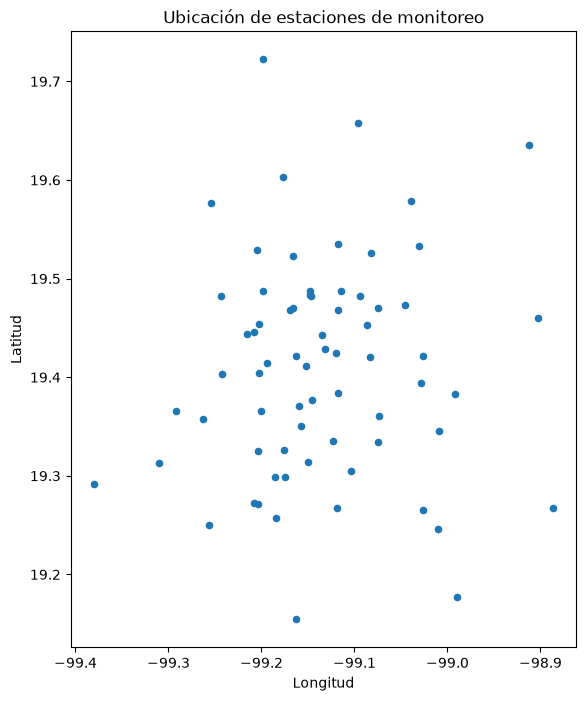

In [28]:
estaciones_gdf.plot(
    figsize=(8,8),
    markersize=20
)

plt.title("Ubicación de estaciones de monitoreo")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

### Interpretación de la gráfica

La visualización confirma que las coordenadas geográficas del catálogo de estaciones fueron procesadas correctamente mediante GeoPandas. Cada punto representa una estación de monitoreo atmosférico y su ubicación espacial dentro de la zona de estudio. Esta validación permite comprobar que el catálogo puede utilizarse para integrar las mediciones de PM2.5 y variables meteorológicas con la cartografía de la Ciudad de México en las siguientes etapas del proyecto.

## 5. Integración con la cartografía de la Ciudad de México

En esta sección se cargará la cartografía de las alcaldías de la Ciudad de México y se superpone la ubicación de las estaciones de monitoreo, con el propósito de validar la integración entre información geográfica y datos ambientales.

In [29]:
ruta_alcaldias = Path(
    "../datos/datos_limpios/dataset_limpios/dataset_limpios/Geografia/Alcaldias_CDMX_Limpio.gpkg"
)

alcaldias = gpd.read_file(ruta_alcaldias)

print("Cartografía cargada correctamente")

Cartografía cargada correctamente


In [30]:
alcaldias.head()

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((-99.18231 19.50748, -99.18229 19.507..."
1,09003,09,003,Coyoacán,"POLYGON ((-99.13427 19.35654, -99.13397 19.356..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((-99.25738 19.40112, -99.25698 19.400..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((-99.11124 19.5615, -99.11485 19.5576..."
4,09006,09,006,Iztacalco,"POLYGON ((-99.05751 19.40673, -99.05753 19.406..."


In [31]:
alcaldias.shape

(16, 5)

In [32]:
alcaldias.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [33]:
estaciones_mapa = estaciones_gdf.to_crs(alcaldias.crs)

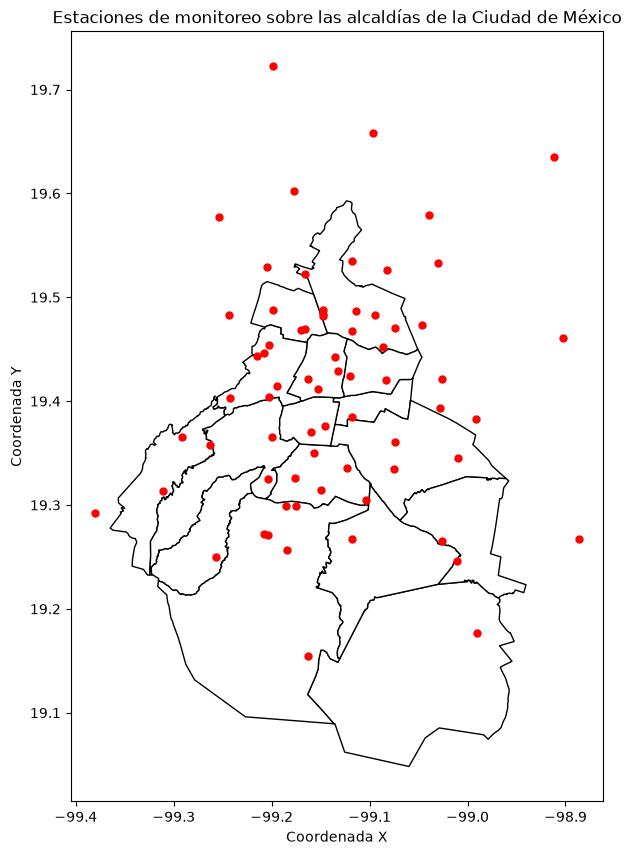

In [34]:
ax = alcaldias.plot(
    figsize=(10,10),
    edgecolor="black",
    facecolor="white"
)

estaciones_mapa.plot(
    ax=ax,
    color="red",
    markersize=25
)

plt.title("Estaciones de monitoreo sobre las alcaldías de la Ciudad de México")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.show()

# 6. Pipeline preliminar de procesamiento

Una vez explorados los datasets, se propone el siguiente flujo de procesamiento para integrar la información ambiental, meteorológica y geográfica:

1. Obtención de los datasets de PM2.5, meteorología, catálogo de estaciones y cartografía.
2. Lectura de los archivos mediante Python.
3. Validación de la estructura, tipos de datos y dimensiones.
4. Identificación de estaciones comunes entre los datasets.
5. Integración de la información mediante FECHA, HORA y ESTACIÓN.
6. Asociación de las estaciones con sus coordenadas geográficas.
7. Integración con la cartografía de la Ciudad de México.
8. Generación de un dataset consolidado para el análisis.
9. Aplicación de modelos de aprendizaje automático.
10. Generación de mapas de zonas críticas de contaminación.

# 7. Arquitectura experimental propuesta

La arquitectura propuesta para el proyecto está conformada por cuatro componentes principales:

## Fuentes de datos
- PM2.5 (SIMAT)
- Variables meteorológicas (REDMET)
- Catálogo de estaciones
- Cartografía de la Ciudad de México (INEGI)

## Procesamiento
El procesamiento de la información se realizará mediante Python utilizando las bibliotecas Pandas y GeoPandas para la lectura, validación e integración de los datasets.

## Integración
Los datasets se relacionarán utilizando las variables FECHA, HORA y ESTACIÓN, complementando la información espacial mediante el catálogo de estaciones.

## Resultados
El dataset integrado será utilizado posteriormente para el entrenamiento de modelos de aprendizaje automático y la identificación de zonas críticas de contaminación atmosférica mediante herramientas GIS.